# **SOCIAL MEDIA MENTAL HEALTH**

### Dataset Background


  Dataset: Social Media Mental Health Indicators

  Source: Kaggle

  Access: Path created to root dataset to notebook
  (Link below to Kaggle dataset as well)
  
  Note: Data set is fully synthetic

  More Info: https://www.kaggle.com/datasets/sonalshinde123/social-media-mental-health-indicators-dataset/data

In [ ]:
# import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# create path from kaggle
import kagglehub

# Download latest version
path = kagglehub.dataset_download("sonalshinde123/social-media-mental-health-indicators-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'social-media-mental-health-indicators-dataset' dataset.
Path to dataset files: /kaggle/input/social-media-mental-health-indicators-dataset


The dataset look into mental health with a focus on the effect social media has on one's mental health. Also taking into consideration factors like age, sleep, physical activity, and positive/negative interactions.

I chose this dataset because I found the topic to be interesting. Social media concerns and affect on people has been a largely controversial topic, especially with the youth. The data also has a decent size with 5,000 rows and 15 columns to explore.

In [ ]:
# load data
df = pd.read_csv(f"{path}/mental_health_social_media_dataset.csv")
df.head()

,person_name,age,date,gender,platform,daily_screen_time_min,social_media_time_min,negative_interactions_count,positive_interactions_count,sleep_hours,physical_activity_min,anxiety_level,stress_level,mood_level,mental_state
0,Reyansh Ghosh,35,1/1/2024,Male,Instagram,320,160,1,2,7.4,28,2,7,6,Stressed
1,Neha Patel,24,1/12/2024,Female,Instagram,453,226,1,3,6.7,15,3,8,5,Stressed
2,Ananya Naidu,26,1/6/2024,Male,Snapchat,357,196,1,2,7.2,24,3,7,6,Stressed
3,Neha Das,66,1/17/2024,Female,Snapchat,190,105,0,1,8.0,41,2,6,6,Stressed
4,Reyansh Banerjee,31,1/28/2024,Male,Snapchat,383,211,1,2,7.1,22,3,7,6,Stressed


In [ ]:
# dataframe's columns
df.columns

Index(['person_name', 'age', 'date', 'gender', 'platform',
       'daily_screen_time_min', 'social_media_time_min',
       'negative_interactions_count', 'positive_interactions_count',
       'sleep_hours', 'physical_activity_min', 'anxiety_level', 'stress_level',
       'mood_level', 'mental_state'],
      dtype='object')

In [ ]:
# dataframe's shape
df.shape

(5000, 15)

### Exploratory Data Analysis

.describe(): To understand mean, median, max, and other descriptive statistics. Get an idea of the data and identify any concerning numbers. Daily screen time and social media time both seem to be in acceptable range. All participants have at least a minimum of 35 minutes of social media to accurately determine its effect on mental state.

In [ ]:
df.describe()

,age,daily_screen_time_min,social_media_time_min,negative_interactions_count,positive_interactions_count,sleep_hours,physical_activity_min,anxiety_level,stress_level,mood_level
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,29.947800,373.058200,175.331600,0.864200,1.835400,7.134660,22.693400,2.510400,7.107600,5.625800
std,12.279936,106.003916,71.209329,0.555176,0.943443,0.533184,10.602862,0.794996,1.062378,0.759928
min,13.000000,140.000000,35.000000,0.000000,0.000000,6.400000,8.000000,1.000000,5.000000,4.000000
25%,21.000000,310.000000,118.000000,1.000000,1.000000,6.700000,14.000000,2.000000,6.000000,5.000000
50%,27.000000,388.000000,170.000000,1.000000,2.000000,7.100000,21.000000,3.000000,7.000000,6.000000
75%,35.250000,461.000000,231.000000,1.000000,2.000000,7.450000,29.000000,3.000000,8.000000,6.000000
max,69.000000,520.000000,338.000000,2.000000,4.000000,8.300000,46.000000,4.000000,9.000000,7.000000


.info(): Check to see if there are any null values and dtypes of columns. Only objects, floats, and int. No null values found and date is considered an object

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 15 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   person_name                  5000 non-null   object 
 1   age                          5000 non-null   int64  
 2   date                         5000 non-null   object 
 3   gender                       5000 non-null   object 
 4   platform                     5000 non-null   object 
 5   daily_screen_time_min        5000 non-null   int64  
 6   social_media_time_min        5000 non-null   int64  
 7   negative_interactions_count  5000 non-null   int64  
 8   positive_interactions_count  5000 non-null   int64  
 9   sleep_hours                  5000 non-null   float64
 10  physical_activity_min        5000 non-null   int64  
 11  anxiety_level                5000 non-null   int64  
 12  stress_level                 5000 non-null   int64  
 13  mood_level        

.drop(): dropping column with person_name to clean and for subject privacy concerns

In [ ]:
df = df.drop('person_name', axis=1)
df.head()

,age,date,gender,platform,daily_screen_time_min,social_media_time_min,negative_interactions_count,positive_interactions_count,sleep_hours,physical_activity_min,anxiety_level,stress_level,mood_level,mental_state
0,35,1/1/2024,Male,Instagram,320,160,1,2,7.4,28,2,7,6,Stressed
1,24,1/12/2024,Female,Instagram,453,226,1,3,6.7,15,3,8,5,Stressed
2,26,1/6/2024,Male,Snapchat,357,196,1,2,7.2,24,3,7,6,Stressed
3,66,1/17/2024,Female,Snapchat,190,105,0,1,8.0,41,2,6,6,Stressed
4,31,1/28/2024,Male,Snapchat,383,211,1,2,7.1,22,3,7,6,Stressed


Convert data dtype from object into datetime for easier usuablitly and filter option by date. date column was an object but might be more useful for to be a datetype.

In [ ]:
print(df['date'])

0        1/1/2024
1       1/12/2024
2        1/6/2024
3       1/17/2024
4       1/28/2024
          ...    
4995    1/21/2025
4996    1/26/2025
4997     2/6/2025
4998    2/17/2025
4999    2/28/2025
Name: date, Length: 5000, dtype: object


In [ ]:
df['date'] = pd.to_datetime(df['date'])
print(df['date'])

0      2024-01-01
1      2024-01-12
2      2024-01-06
3      2024-01-17
4      2024-01-28
          ...    
4995   2025-01-21
4996   2025-01-26
4997   2025-02-06
4998   2025-02-17
4999   2025-02-28
Name: date, Length: 5000, dtype: datetime64[ns]


.value_counts(): Look into categorical data to gain more information and see how evenly distributed. Mental_state can be either stressed, healthy or at risk with a large majority of subjects considered stressed. Gender is fairly evenly distributed between Female and Male with a small portion of Other. The seven platforms in the dataset are also fairly evenly distributed.


In [ ]:
df['mental_state'].value_counts()

,count
mental_state,
Stressed,4601
Healthy,341
At_Risk,58


In [ ]:
df['gender'].value_counts()

,count
gender,
Female,2474
Male,2427
Other,99


In [ ]:
df['platform'].value_counts()

,count
platform,
Facebook,744
TikTok,723
YouTube,716
WhatsApp,710
Snapchat,705
Instagram,703
Twitter,699


Histplot: Get an idea of some feature distribution like age and social media time. Both graphs below are right skewed and able to identify peaks. Age seems to be pretty heavily right skewed, while social media time is only slightly skewed. The highest peak for age is around 20-25 years old.

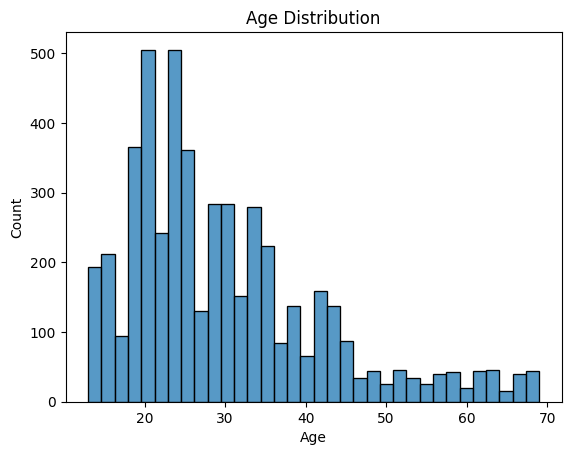

In [ ]:
sns.histplot(df['age'])
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

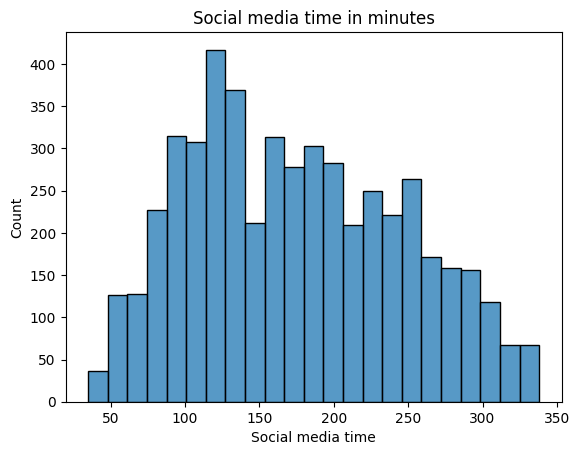

In [ ]:
sns.histplot(df['social_media_time_min'])
plt.title('Social media time in minutes')
plt.xlabel('Social media time')
plt.ylabel('Count')
plt.show()

### Research Questions & Analysis

#### **Question #1:** How does the social media time affect the distribution of the 3 mental states?

1. **Choice:** I wanted to get deeper into the three mental states of stressed, healthy, and at risk and look into if social media time has an effect on the distribution. Already determine high amount of subjects presented as stressed, but how does that present distribution wise. I thought a box pot would be the perfect visual representation because you can easily see where the median, quartiles, and most of the data lies for each of the mental states, as well as an easy visual comparison. I also chose a line plot to see if the date had any further affect.

2. **Plot:**

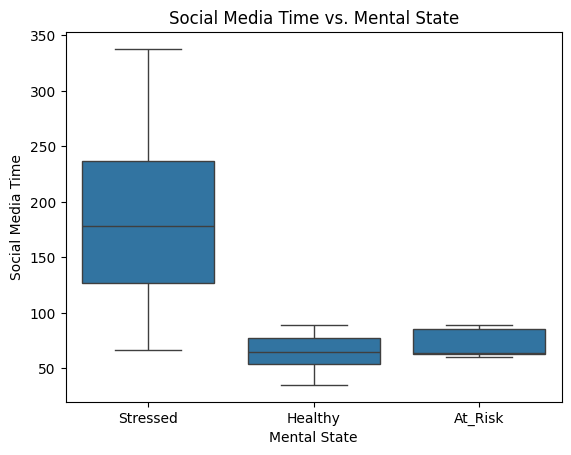

In [ ]:
# boxplot social media time vs mental state
sns.boxplot(data = df, x= 'mental_state', y = 'social_media_time_min')
plt.title('Social Media Time vs. Mental State')
plt.xlabel('Mental State')
plt.ylabel('Social Media Time')
plt.show()

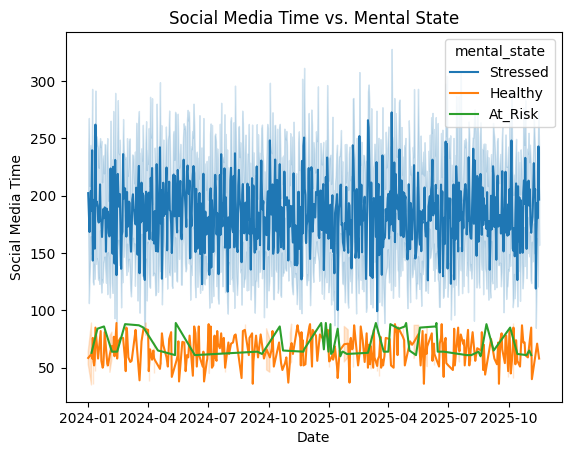

In [ ]:
sns.lineplot(data = df, x= 'date', y = 'social_media_time_min', hue = 'mental_state')
plt.title('Social Media Time vs. Mental State')
plt.xlabel('Date')
plt.ylabel('Social Media Time')
plt.show()

3. **Inference:** From these visual representations, it is easy to determine that there is some type of correlation between higher social media time and stressed individuals. We are, however, not able to determine if they determine if there’s some type of causation. For healthy and at risk mental states have significantly lower social media time. At risk still being slightly higher, however they’re still fairly similar and barely higher in social media time than healthy mental states. Date does not seem to have a large effect staying within a certain range with few peaks.

#### **Question #2:** How do social media time, sleep hours, mood level, etc. affect each other?

1. **Choice:**  I chose a correlation heat map to see how some of the features affect each other and how strong the correlations are. Including features like social media time, sleep, physical activity, and mood level. A heat map is a great visualization to show in color how strong the relationships are. I want to focus on how social media time, sleep hours, physical activity, affect anxiety, stress, and mood level


2. Plot/Model:

In [ ]:
df_filtered = df[['social_media_time_min', 'sleep_hours', 'physical_activity_min', 'anxiety_level', 'stress_level', 'mood_level']]

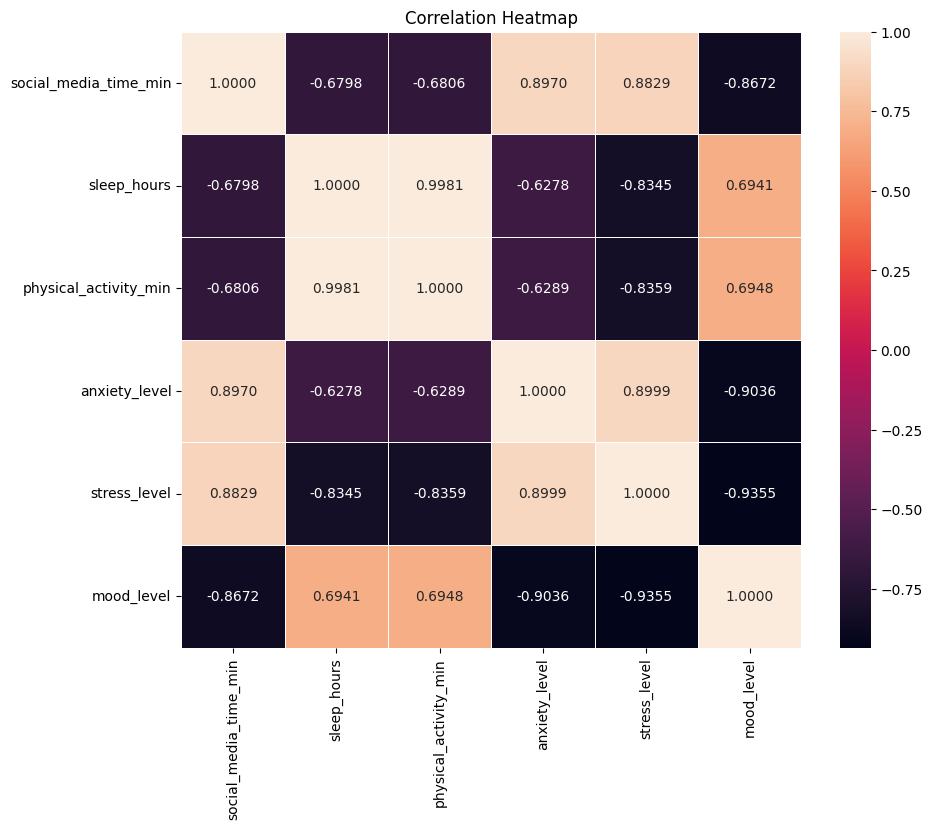

In [ ]:
plt.figure(figsize=(10,8))
plt.title('Correlation Heatmap')
sns.heatmap(df_filtered.corr(),annot=True, fmt=".4f",  linewidths=0.5) # use center=0 to center color mapping to 0
plt.show()

3. **Inference:** From our heat map we were able to see very strong negative and positive correlations between each other. The correlations such as mood level with anxiety and stress are already expected. However, a significant one note is a strong negative correlation between mood level and social media time (-0.8672). As well as other strong negative correlations such as sleep hours with stress levels and physical activity with stress levels. From our correlation heat map we’re able to see that there’s not really a lot of those middle tones (no/slight correlation).

#### **Question #3:** Can your use a Decision Tree model to predict mental state?



1. **Choice:** I chose a random forest tree model because I thought it would be easy to interpret. It is great for this type of data and to model a classifier target. Given that our target has three options of either at risk, healthy or stressed, I thought the branches would be an easy way to organize them into these bins.

2. **Model:**

In [ ]:
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,confusion_matrix

Encoder to transform catorgorical object into numerical data to make it easier for our model to interpret

In [ ]:
label_encoder = LabelEncoder()
df['mental_state'] = label_encoder.fit_transform(df['mental_state'])
label_mapping = {class_label: index for index, class_label in enumerate(label_encoder.classes_)}
label_mapping

{'At_Risk': 0, 'Healthy': 1, 'Stressed': 2}

In [ ]:
df['gender'] = label_encoder.fit_transform(df['gender'])
label_mapping = {class_label: index for index, class_label in enumerate(label_encoder.classes_)}
label_mapping

{'Female': 0, 'Male': 1, 'Other': 2}

In [ ]:
df['platform'] = label_encoder.fit_transform(df['platform'])
label_mapping = {class_label: index for index, class_label in enumerate(label_encoder.classes_)}
label_mapping

{'Facebook': 0,
 'Instagram': 1,
 'Snapchat': 2,
 'TikTok': 3,
 'Twitter': 4,
 'WhatsApp': 5,
 'YouTube': 6}

In [ ]:
df.head()

,age,date,gender,platform,daily_screen_time_min,social_media_time_min,negative_interactions_count,positive_interactions_count,sleep_hours,physical_activity_min,anxiety_level,stress_level,mood_level,mental_state
0,35,2024-01-01,1,1,320,160,1,2,7.4,28,2,7,6,2
1,24,2024-01-12,0,1,453,226,1,3,6.7,15,3,8,5,2
2,26,2024-01-06,1,2,357,196,1,2,7.2,24,3,7,6,2
3,66,2024-01-17,0,2,190,105,0,1,8.0,41,2,6,6,2
4,31,2024-01-28,1,2,383,211,1,2,7.1,22,3,7,6,2


In [ ]:
X = df.drop(columns = ['mental_state', 'date'])
y = df['mental_state']

In [ ]:
model = DecisionTreeClassifier(max_leaf_nodes=len(X.columns))

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
model.fit(X_train, y_train)

DecisionTreeClassifier(max_leaf_nodes=12)

In [ ]:
predictions = model.predict(X_test)

In [ ]:
print(predictions)
print(y_test)

[2 2 2 2 2 2 2 2 2 2 2 2 2 2 1 2 2 2 2 2 2 2 2 2 2 2 2 2 0 2 2 2 2 2 1 2 2
 2 2 2 2 2 2 2 2 2 2 2 1 2 2 2 2 2 2 2 2 2 1 2 2 2 2 2 2 2 2 2 2 2 2 2 1 1
 2 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 1 2 2 2 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 1 2 1 2 2 2 2 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 1 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 1 2 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 1 2 2 2 2
 2 2 2 2 2 2 2 2 1 2 2 2 2 2 2 2 2 1 2 2 2 2 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 1 2 2 2 2 2 2 2 2 2 2 2 2 2 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 1 2 1 2 2 0 2 2 2 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 1 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 0 2 2 2 2 2 2 1 2 2 2 2 2 2 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 1 2 0 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 1 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 1 2 2 2 2 2 2 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 1 2 2 2 2 2 0 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 1 2 2 2 2 2 2 1 2 2 2
 1 2 2 2 1 2 2 2 2 2 2 1 2 2 2 0 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 

In [ ]:
acc_score = accuracy_score(y_test,predictions)
acc_score

1.0

3. **Inference:** Our decision tree model after being trained and computing an accurate score, produced a score of 1.0 or 100%. Which in theory sounds great, however the fact that it’s 100% is quite concerning. This could be due to overfitting the model producing a score too accurate with no errors, a need to tune/ refine hyperparameters for the model, or might point to some issues with the original data source. Given that our original data source is synthetic and produced by some type of artificial intelligence, it could be that the data doesn’t vary enough like real subjects  and that might be why our model is coming out with an accuracy score that is too high.

### Findings


Given the data was artificially generated, it makes me question how accurately the data stimulates real life people. As well as put into question, the original sources that went into training and creating the data set. The data seems to be personifying the average person, for example, for sleep hours there is a minimum of 6.4 and the max is 8.3 which seems a small range for sleep hours. Doesn’t count for people who may sleep a lot or may sleep very little.


Even though the data set is synthetic, the column person_name could bring up the concern of using people’s names on data sets. The need to conceal one’s identity or maybe instead of documenting someone’s name using a number identifier for subjects. The data was synthetic, which makes me question why they felt the need to put a name when not necessary.


Looking at the divide between mental states of stressed, healthy, and at_risk, there is a concerning amount of people who are stressed and very little (341 people out of 5000) are considered healthy. Is this measure being accurately drawn? Or are there truly that many concerning people who are stressed from social media interaction?


The platform data is fairly even distributed between 7 category options, which does not seem realistic for a random generated data set. The data set is between 2024 and 2025, and platforms that aren’t seemingly popular are equal  with the numbers for popular platforms within that date range.


### Additional visualizations:

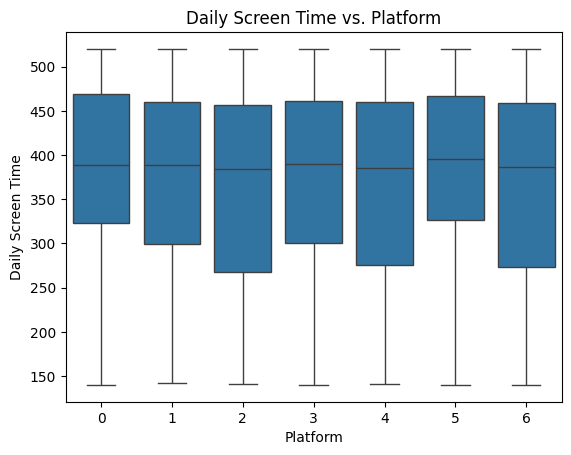

In [ ]:
sns.boxplot(data = df, x= 'platform', y = 'daily_screen_time_min')
plt.title('Daily Screen Time vs. Platform')
plt.xlabel('Platform')
plt.ylabel('Daily Screen Time')
plt.show()

Text(0, 0.5, 'Mood Level')

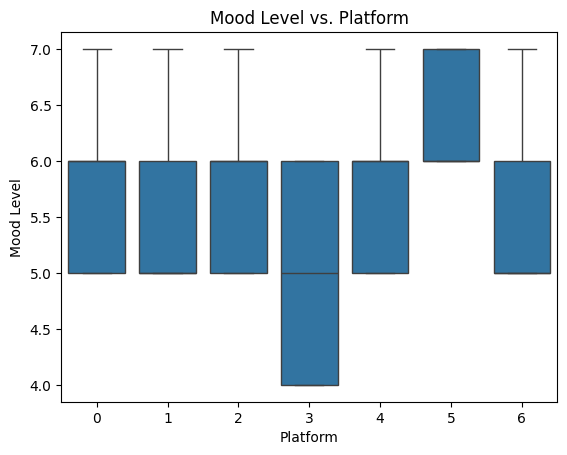

In [ ]:
sns.boxplot(data = df, x= 'platform', y = 'mood_level')
plt.title('Mood Level vs. Platform')
plt.xlabel('Platform')
plt.ylabel('Mood Level')